In [18]:
from langgraph.graph import StateGraph,START,END 
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from typing import TypedDict, Literal
from pydantic import BaseModel , Field

In [19]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discriminant: int  # <-- Added the missing 'c' here
    result: str

In [20]:
def show_equation(state: QuadState) -> QuadState:
    equation = f'{state['a']}x2{state['b']}x {state['c']}'
    
    return {'equation' : equation}

def calculate_discriminant(state: QuadState) -> QuadState:
    discriminant = state['b']**2 - (4 * state['a'] * state['c'])
    return {'discriminant': discriminant}

def real_root(state: QuadState) -> QuadState:

    root1 = (-state['b'] + state['discriminant']**0.5) / (2 * state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2 * state['a'])

    result = f'The roots are real and distinct: {root1} and {root2}'

    return {'result': result}


def repeated_root(state: QuadState) -> QuadState:

    root = (-state['b']) / (2 * state['a'])

    result = f'The root is repeated: {root}'

    return {'result': result}

def no_real_root(state: QuadState) -> QuadState:

    result = 'The equation has no real roots.'

    return {'result': result}


def conditional_workflow(state: QuadState) -> Literal["real_root", "repeated_root", "no_real_root"]:
    discriminant = state['discriminant']
    if discriminant > 0:
        return "real_root"
    elif discriminant == 0:
        return "repeated_root"
    else:
        return "no_real_root"

    


In [21]:
graph = StateGraph(QuadState)

graph.add_node('Show the equation' ,show_equation)
graph.add_node('Calculate the discriminant', calculate_discriminant)
graph.add_node('real root', real_root)
graph.add_node('repeated root', repeated_root)
graph.add_node('no real root', no_real_root)



graph.add_edge(START, 'Show the equation')
graph.add_edge('Show the equation', 'Calculate the discriminant')


graph.add_conditional_edges('Calculate the discriminant', conditional_workflow, {
    "real_root": "real root",
    "repeated_root": "repeated root",
    "no_real_root": "no real root"
})

workflow = graph.compile()


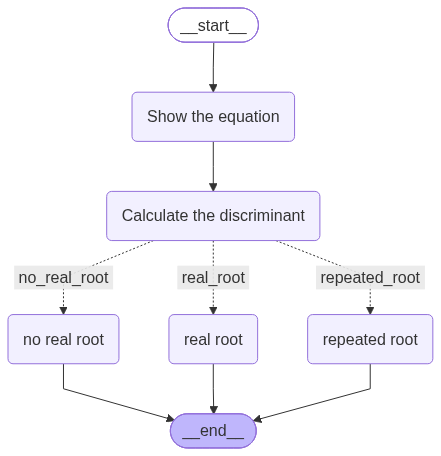

In [22]:
workflow

In [23]:
initial_state = {
    'a': 1,
    'b': -3,
    'c': 2
}
# Run the graph instead of trying to draw it
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 1, 'b': -3, 'c': 2, 'equation': '1x2-3x 2', 'discriminant': 1, 'result': 'The roots are real and distinct: 2.0 and 1.0'}
